# 7. Migration & new possibilities — driven by a real detector

This notebook does two things at once:

1. **Migrates a real 1.x tracker to 2.0.** We take the
   appearance-embedding tracker from the
   [migration guide](../../docs/migration.md) and rebuild it in
   the 2.0 syntax, then run it on detections from an actual
   pretrained model.
2. **Showcases what 2.0 makes possible** that 1.x could not
   express: parallel cost fusion, cascaded matching, lifecycle
   policies, and end-to-end **differentiable** matching.

Everything runs locally on CPU. The detections come from a tiny
Hugging Face detector (`hustvl/yolos-tiny`, ~6M params) plus a
torchvision ResNet-18 appearance encoder — both download their
weights on first run. If the model or network is unavailable, the
notebook falls back to a deterministic synthetic seed so it still
runs end to end.


## Setup

Install the extra dependencies once (the core library needs only
`unitrack`; this notebook adds a detector and plotting):


In [1]:
# One-time install. Comment out after the first run.
%pip install -q "transformers>=4.40" torchvision matplotlib pillow


/home/khwstolle/Projects/research/unitrack/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import urllib.request

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import torch

import unitrack as ut
from unitrack.assignment import Associate, Jonker, SoftAssignment
from unitrack.costs import BoxIoU, Cosine
from unitrack.data import (
    Detections, FrameContext, TensorSpec, Tracklets,
)
from unitrack.gates import ClassGate, ScoreGate
from unitrack.lifecycle import (
    ConfirmedOnly, IncludeAll, NoLifecycle, StandardLifecycle,
    TrackletStatus,
)
from unitrack.pipeline import Gated, Parallel, Pipe, Sequential
from unitrack.pipeline.merge import WeightedSum
from unitrack.states import (
    FromDetectionField, Identity, Replace, State,
)

torch.manual_seed(0)
plt.rcParams["figure.figsize"] = (7, 4)


## A real, lightweight detector + appearance encoder

unitrack tracks; it does not detect. In a real pipeline the
per-frame detections come from an object detector, and the
appearance embeddings from a ReID encoder. We use:

- **Detector** — `hustvl/yolos-tiny` via 🤗 Transformers. Returns
  boxes (xyxy, pixels), class labels, and scores.
- **Appearance** — torchvision `ResNet-18` with its classification
  head removed, giving a 512-d feature per cropped box. We
  L2-normalise it so a cosine cost is well-behaved.

These are exactly the four fields the migrated tracker consumes:
`bbox`, `category`, `score`, and `reid`.


In [3]:
def load_detector_and_encoder():
    """Load a tiny HF detector + a torchvision ReID encoder."""
    import torchvision
    from transformers import (
        AutoImageProcessor, AutoModelForObjectDetection,
    )

    processor = AutoImageProcessor.from_pretrained("hustvl/yolos-tiny")
    detector = AutoModelForObjectDetection.from_pretrained(
        "hustvl/yolos-tiny"
    ).eval()

    weights = torchvision.models.ResNet18_Weights.DEFAULT
    encoder = torchvision.models.resnet18(weights=weights)
    encoder.fc = torch.nn.Identity()  # expose the 512-d features
    encoder.eval()
    return processor, detector, encoder, weights.transforms()


@torch.no_grad()
def detect_and_embed(image, bundle, *, score_thr=0.7):
    """Detect objects and attach a 512-d appearance embedding each."""
    processor, detector, encoder, crop_tf = bundle
    inputs = processor(images=image, return_tensors="pt")
    outputs = detector(**inputs)
    target_sizes = torch.tensor([[image.height, image.width]])
    out = processor.post_process_object_detection(
        outputs, threshold=score_thr, target_sizes=target_sizes
    )[0]
    boxes, labels, scores = out["boxes"], out["labels"], out["scores"]

    crops = []
    for x0, y0, x1, y1 in boxes.tolist():
        x1, y1 = max(x1, x0 + 1), max(y1, y0 + 1)  # guard degenerate boxes
        crops.append(crop_tf(image.crop((x0, y0, x1, y1))))
    reid = (
        torch.nn.functional.normalize(encoder(torch.stack(crops)), dim=-1)
        if crops else torch.zeros(0, 512)
    )
    names = [detector.config.id2label[int(c)] for c in labels]
    return {
        "boxes": boxes.float(), "category": labels.long(),
        "score": scores.float(), "reid": reid.float(), "names": names,
    }


Run the detector on one image. We use a stock multi-object photo;
point `IMAGE_URL` (or a local `IMAGE_PATH`) at your own to try it
on something else. If anything fails — no network, deps missing —
we drop to a deterministic synthetic seed and keep going.


In [4]:
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"


def synthetic_seed(reid_dim=512):
    """Offline stand-in: three objects, two sharing a class."""
    g = torch.Generator().manual_seed(0)
    q, _ = torch.linalg.qr(torch.randn(reid_dim, reid_dim, generator=g))
    return {
        "boxes": torch.tensor([[10., 10, 40, 60],
                               [120, 20, 150, 70],
                               [220, 15, 250, 65]]),
        "category": torch.tensor([1, 1, 2]),
        "score": torch.tensor([0.95, 0.9, 0.8]),
        "reid": q[:3],
        "names": ["cat", "cat", "remote"],
    }


image = None
try:
    from PIL import Image
    bundle = load_detector_and_encoder()
    image = Image.open(urllib.request.urlopen(IMAGE_URL)).convert("RGB")
    seed = detect_and_embed(image, bundle)
    if seed["boxes"].shape[0] == 0:
        raise RuntimeError("detector found no objects above threshold")
    SOURCE = f"hugging face yolos-tiny ({len(seed['names'])} detections)"
except Exception as exc:  # noqa: BLE001 — any failure -> deterministic seed
    print(f"[fallback] real model unavailable "
          f"({type(exc).__name__}: {exc}); using a synthetic seed.")
    seed = synthetic_seed()
    SOURCE = "synthetic fallback"

REID_DIM = seed["reid"].shape[1]
print(f"source:  {SOURCE}")
print(f"objects: {seed['names']}")
print(f"scores:  {seed['score'].round(decimals=2).tolist()}")


[fallback] real model unavailable (ModuleNotFoundError: No module named 'transformers'); using a synthetic seed.
source:  synthetic fallback
objects: ['cat', 'cat', 'remote']
scores:  [0.949999988079071, 0.8999999761581421, 0.800000011920929]


In [5]:
# Show the detections on the image (or list them in the fallback case).
if image is not None:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(image)
    for (x0, y0, x1, y1), name, sc in zip(
        seed["boxes"].tolist(), seed["names"], seed["score"].tolist()
    ):
        ax.add_patch(mpatches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, edgecolor="lime", linewidth=2))
        ax.text(x0, y0 - 4, f"{name} {sc:.2f}", color="lime",
                fontsize=9,
                bbox=dict(facecolor="black", alpha=0.5, pad=1))
    ax.set_axis_off()
    ax.set_title(f"Detections from {SOURCE}")
    plt.show()
else:
    for name, box in zip(seed["names"], seed["boxes"].tolist()):
        print(f"  {name:8s} bbox={[round(v, 1) for v in box]}")


  cat      bbox=[10.0, 10.0, 40.0, 60.0]
  cat      bbox=[120.0, 20.0, 150.0, 70.0]
  remote   bbox=[220.0, 15.0, 250.0, 65.0]


## From one image to a clip

Tracking needs a *sequence*. We synthesize one from the single set
of real detections: each frame pans the camera by a fixed vector,
shuffles the detection order (so the tracker can't cheat on row
alignment), and jitters the appearance embeddings slightly. The
motion is deterministic, so every tracker below sees the identical
clip — differences in their output come from the tracker, not the
data.


In [6]:
def make_clip(seed, *, n_frames=8, pan=(15.0, 4.0), drop=()):
    M = seed["boxes"].shape[0]
    pan_v = torch.tensor([pan[0], pan[1], pan[0], pan[1]])
    g = torch.Generator().manual_seed(1)
    clip = []
    for k in range(n_frames):
        if k in drop:  # a missed-detection / occlusion frame
            clip.append(Detections(
                index=torch.zeros(0, dtype=torch.int64),
                reid=torch.zeros(0, REID_DIM), bbox=torch.zeros(0, 4),
                centroid=torch.zeros(0, 2),
                category=torch.zeros(0, dtype=torch.int64),
                score=torch.zeros(0), batch_size=[0]))
            continue
        boxes = seed["boxes"] + k * pan_v
        centroid = torch.stack(
            [(boxes[:, 0] + boxes[:, 2]) / 2,
             (boxes[:, 1] + boxes[:, 3]) / 2], dim=-1)
        reid = seed["reid"] + 0.01 * torch.randn(
            M, REID_DIM, generator=g)
        reid = torch.nn.functional.normalize(reid, dim=-1)
        order = torch.randperm(M, generator=g)
        clip.append(Detections(
            index=torch.arange(M, dtype=torch.int64),
            reid=reid[order], bbox=boxes[order], centroid=centroid[order],
            category=seed["category"][order], score=seed["score"][order],
            batch_size=[M]))
    return clip

clip = make_clip(seed)
print(f"clip: {len(clip)} frames x {seed['boxes'].shape[0]} detections")


clip: 8 frames x 3 detections


## Are the objects separable by appearance?

The migrated tracker matches on the `reid` embedding, so before
running it, it's worth asking whether the embeddings actually
tell the objects apart. The cosine similarity below is 1 on the
diagonal; small off-diagonal values mean the cue is informative.
Two objects of the same class (e.g. two cats) will show a higher
off-diagonal value — exactly the case where motion has to help.


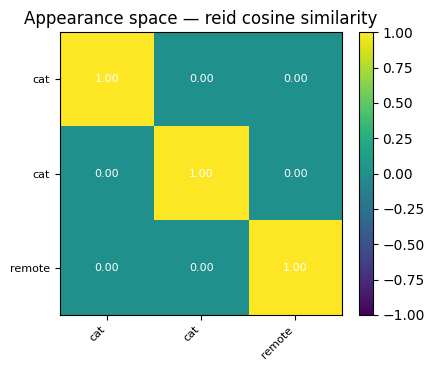

In [7]:
sim = seed["reid"] @ seed["reid"].T   # reid rows are L2-normalized
fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(sim.numpy(), cmap="viridis", vmin=-1, vmax=1)
ax.set_title("Appearance space — reid cosine similarity")
n = len(seed["names"])
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(seed["names"], rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(seed["names"], fontsize=8)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                color="white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## The 1.x tracker we're migrating

In unitrack 1.x the appearance tracker was built like this (see the
[migration guide](../../docs/migration.md) for the full before /
after and the symbol-by-symbol mapping):

```python
# --- unitrack 1.x ---
cost = ut.costs.Cosine(field="reid")
cost = ut.costs.GateCost("category").wrap(cost)        # gate fused into cost
tracker = ut.SimpleTracker(
    tracker=ut.MultiStageTracker(
        fields=[_build_field("reid"), _build_field("score"), ...],
        stages=[ut.stages.Gate(gate=SelectAndFilter("score", min_score),
                then=[ut.stages.Association(
                    cost=cost,
                    assignment=ut.assignment.Jonker(threshold=0.9))])],
    ),
    memory=ut.TrackletMemory(states={
        "reid": ut.states.Value(torch.float, shape=(512,)), ...}),
)
```

Field-selection modules at the front, gating fused into the cost,
states living on the memory, and a `SimpleTracker` bundling
tracker + memory.


## Step 1 — the same tracker, in 2.0

The 2.0 version reads as a small tree. Gates are first-class
(`ClassGate`, `ScoreGate`) and combine with `Sequential`; `Gated`
applies them to a `Pipe` that turns a `Cosine` cost into a match.
States move onto the `Tracker` as `(Process, Observation,
Initializer)` triples — a plain appearance cache is
`Identity` + `Replace` + `FromDetectionField`.


In [8]:
def feature_state(name, shape, dtype):
    """A pure cache: no motion model, replace on match, seed from det."""
    return State(
        schema=TensorSpec(shape=shape, dtype=dtype),
        process=Identity(name), observation=Replace(name),
        init=FromDetectionField(name))

STATES = {
    "reid": feature_state("reid", (REID_DIM,), torch.float32),
    "bbox": feature_state("bbox", (4,), torch.float32),
    "centroid": feature_state("centroid", (2,), torch.float32),
    "category": feature_state("category", (), torch.int64),
    "score": feature_state("score", (), torch.float32),
}

def make_tracker(root, *, lifecycle=None, visibility=None):
    return ut.Tracker(
        root=root, states=dict(STATES),
        lifecycle=lifecycle or NoLifecycle(),
        visibility=visibility or IncludeAll())

def run_clip(tracker, clip):
    ms = ut.MultiStream(tracker)
    return [ms.step(0, d, FrameContext.make(k, fps=15.0, stream_key=0))
            for k, d in enumerate(clip)]

def distinct_ids(results):
    ids = set()
    for r in results:
        ids.update(r.snapshot.id.tolist())
    return sorted(ids)


In [9]:
appearance_tracker = make_tracker(
    Gated(
        gate=Sequential([
            ClassGate("category"),          # cat can't match remote
            ScoreGate("score", threshold=0.1),
        ]),
        then=Pipe(cost=Cosine("reid"),
                  assoc=Associate(Jonker(threshold=0.3))),
    )
)
app_results = run_clip(appearance_tracker, clip)
print(f"appearance tracker -> stable ids: {distinct_ids(app_results)}")


appearance tracker -> stable ids: [1, 2, 3]


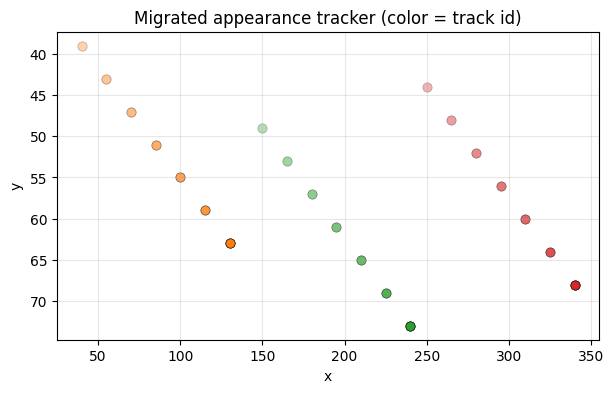

In [10]:
def plot_tracks(results, title, ax):
    cmap = plt.get_cmap("tab10")
    n_frames = max(1, len(results) - 1)
    for k, r in enumerate(results):
        snap = r.snapshot
        for n in range(snap.batch_size[0]):
            c = snap.centroid[n]
            ax.scatter(c[0].item(), c[1].item(),
                       color=cmap(int(snap.id[n]) % 10), s=45,
                       edgecolor="black", linewidth=0.4,
                       alpha=0.35 + 0.65 * k / n_frames)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)
    ax.invert_yaxis()  # image coordinates: y grows downward

fig, ax = plt.subplots()
plot_tracks(app_results,
            "Migrated appearance tracker (color = track id)", ax)
plt.show()


One coherent trajectory per color: the cosine cost re-associates
every shuffled detection to the right identity, exactly as the 1.x
tracker did — but the 2.0 construction is the springboard for
everything below.

## Why one cue isn't enough

The migrated tracker matches on appearance alone. A pure
**motion** tracker (IoU between boxes, à la SORT) is the classic
alternative — but it breaks under fast camera motion: when the pan
between frames exceeds the box size, consecutive boxes don't
overlap, IoU is zero everywhere, and every object spawns a fresh ID
each frame. We size a pan past the box width to force exactly that.


In [11]:
box_w = (seed["boxes"][:, 2] - seed["boxes"][:, 0]).median().item()
clip_fast = make_clip(seed, pan=(1.5 * box_w, 0.0))  # pan > box width

iou_tracker = make_tracker(
    Pipe(cost=BoxIoU("bbox"), assoc=Associate(Jonker(threshold=0.7))))

n_obj = seed["boxes"].shape[0]
iou_ids = distinct_ids(run_clip(iou_tracker, clip_fast))
app_ids = distinct_ids(run_clip(appearance_tracker, clip_fast))
print(f"objects in scene:                 {n_obj}")
print(f"IoU-only ids under a fast pan:    {len(iou_ids)}  (id explosion)")
print(f"appearance ids under a fast pan:  {len(app_ids)}  (stable)")


objects in scene:                 3
IoU-only ids under a fast pan:    18  (id explosion)
appearance ids under a fast pan:  3  (stable)


Appearance survives the pan; IoU collapses. But appearance alone is
fragile the other way — two similar-looking objects that cross
paths can swap IDs, where IoU would have held them apart. Real
trackers want **both** cues. In 1.x, combining them meant a bespoke
cost subclass or an awkward multi-stage hack. 2.0 makes it a
one-liner — two ways.

## New in 2.0 #1 — parallel cost fusion

`Parallel([...], merge=...)` runs several cost producers on the
same snapshot and merges their matrices. `WeightedSum` lets you dial
the appearance/motion balance. The whole fused cost is still a
single `CostProducer`, so it drops straight into a `Pipe`.


In [12]:
fused_tracker = make_tracker(
    Pipe(
        cost=Parallel(
            children=[Cosine("reid"), BoxIoU("bbox")],
            merge=WeightedSum([1.0, 0.5]),   # appearance + 0.5 * motion
        ),
        assoc=Associate(Jonker(threshold=1.0)),
    )
)
fused_results = run_clip(fused_tracker, clip_fast)
print(f"parallel fusion (appearance + IoU) -> ids: "
      f"{distinct_ids(fused_results)}")
print("Stable under the same fast pan that broke IoU-only — "
      "appearance carries it, IoU sharpens it when boxes do overlap.")


parallel fusion (appearance + IoU) -> ids: [1, 2, 3]
Stable under the same fast pan that broke IoU-only — appearance carries it, IoU sharpens it when boxes do overlap.


## New in 2.0 #2 — cascaded matching (ByteTrack-style)

`Sequential([stage1, stage2, ...])` over match-producing stages
chains *residuals*: stage 1 matches what it can, and only the
leftover tracklets and detections flow into stage 2. A strict
appearance pass followed by an IoU fallback is the canonical
two-stage cascade — and it's just a list.


In [13]:
cascaded_tracker = make_tracker(
    Sequential([
        # Stage 1: confident appearance matches only.
        Pipe(cost=Cosine("reid"),
             assoc=Associate(Jonker(threshold=0.2))),
        # Stage 2: IoU fallback on whoever is left.
        Pipe(cost=BoxIoU("bbox"),
             assoc=Associate(Jonker(threshold=0.7))),
    ])
)
cascaded_results = run_clip(cascaded_tracker, clip)
print(f"cascaded (appearance -> IoU) -> ids: "
      f"{distinct_ids(cascaded_results)}")


cascaded (appearance -> IoU) -> ids: [1, 2, 3]


## New in 2.0 #3 — lifecycle & gating

The 1.x embedding tracker had no notion of track birth or death —
every detection was a track, immediately. 2.0 adds a first-class
**lifecycle**: `StandardLifecycle` runs the
`Tentative → Active → Lost → Removed` state machine, and a
**visibility** policy (`ConfirmedOnly`) hides flickering unconfirmed
tracks from the caller. Below, three frames of detections go missing
(an occlusion); a confirmed track goes `Lost`, then re-acquires its
original ID when it reappears — within the `allow_reid` window.


In [14]:
clip_gap = make_clip(seed, n_frames=10, pan=(4.0, 1.0), drop={4, 5, 6})
lifecycle_tracker = make_tracker(
    Gated(gate=ClassGate("category"),
          then=Pipe(cost=Cosine("reid"),
                    assoc=Associate(Jonker(threshold=0.3)))),
    lifecycle=StandardLifecycle(min_hits=2, max_age=2, allow_reid=4),
    visibility=ConfirmedOnly(),
)
ms = ut.MultiStream(lifecycle_tracker)
names = ["Tentative", "Active", "Lost", "Removed"]
rows = []
for k in range(len(clip_gap)):
    res = ms.step(0, clip_gap[k], FrameContext.make(k, fps=15.0))
    snap = res.snapshot
    counts = [int((snap.status == s).sum()) for s in range(4)]
    rows.append(counts)
    present = clip_gap[k].batch_size[0] > 0
    tally = ", ".join(f"{names[s]}={counts[s]}" for s in range(4)
                      if counts[s])
    print(f"frame {k:2d}  {'det ' if present else 'MISS'}  {tally}")


frame  0  det   Tentative=3
frame  1  det   Active=3
frame  2  det   Active=3
frame  3  det   Active=3
frame  4  MISS  Active=3
frame  5  MISS  Active=3
frame  6  MISS  Lost=3
frame  7  det   Active=3
frame  8  det   Active=3
frame  9  det   Active=3


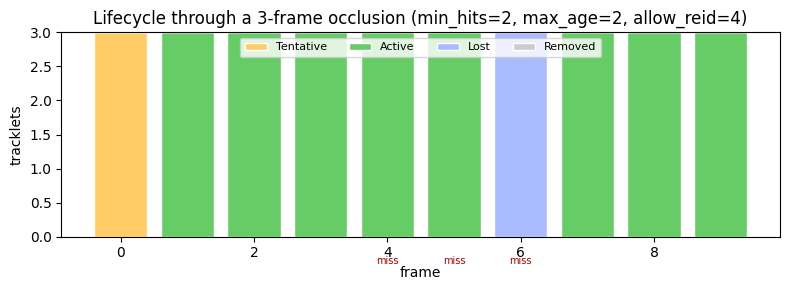

In [15]:
rows_t = torch.tensor(rows)
fig, ax = plt.subplots(figsize=(8, 3))
colors = ["#ffcc66", "#66cc66", "#aabbff", "#cccccc"]
bottom = torch.zeros(len(rows))
for s in range(4):
    ax.bar(range(len(rows)), rows_t[:, s].numpy(), bottom=bottom.numpy(),
           color=colors[s], label=names[s], edgecolor="white")
    bottom = bottom + rows_t[:, s]
for k in range(len(clip_gap)):
    if clip_gap[k].batch_size[0] == 0:
        ax.text(k, -0.4, "miss", ha="center", color="#aa0000", fontsize=7)
ax.set_xlabel("frame"); ax.set_ylabel("tracklets")
ax.set_title("Lifecycle through a 3-frame occlusion "
             "(min_hits=2, max_age=2, allow_reid=4)")
ax.legend(fontsize=8, ncol=4, loc="upper center")
plt.tight_layout(); plt.show()


## New in 2.0 #4 — differentiable matching

The headline capability: with a **soft** assignment, the matching
is differentiable, so a tracking loss can backpropagate into the
embeddings (and through them, the detector backbone). 1.x had no
path to this — the Hungarian solve is a hard, non-differentiable
argmax.

`SoftAssignment` solves an entropy-regularised optimal-transport
problem (Sinkhorn) and exposes the transport plan on
`MatchOutcome.soft_plan`. We build a single soft matching stage,
run it, and backprop a "match the right pairs" loss to the
detection embeddings.


In [16]:
def tracklets_from_reid(reid):
    n = reid.shape[0]
    return Tracklets(
        id=torch.arange(n, dtype=torch.int64),
        status=torch.full((n,), int(TrackletStatus.Active),
                          dtype=torch.int8),
        hits=torch.ones(n, dtype=torch.int32),
        time_since_update=torch.zeros(n, dtype=torch.int32),
        age=torch.ones(n, dtype=torch.int32),
        frame_started=torch.zeros(n, dtype=torch.int32),
        frame_last_seen=torch.zeros(n, dtype=torch.int32),
        reid=reid, batch_size=[n])

cs = tracklets_from_reid(seed["reid"].clone())
torch.manual_seed(7)
det_emb = (seed["reid"] + 0.05 * torch.randn_like(seed["reid"]))
det_emb = det_emb.requires_grad_(True)         # the learnable input
ds = Detections(index=torch.arange(det_emb.shape[0], dtype=torch.int64),
                reid=det_emb, batch_size=[det_emb.shape[0]])

soft_stage = Pipe(cost=Cosine("reid"),
                  assoc=Associate(SoftAssignment(epsilon=0.1)))
match = soft_stage(cs, ds, FrameContext.make(0))
plan = match.soft_plan                          # (N, M), differentiable

loss = -plan.diagonal().sum()                   # reward correct matches
loss.backward()
print(f"soft transport plan shape: {tuple(plan.shape)}")
print(f"plan total mass: {plan.detach().sum().item():.2f}  "
      f"(uniform OT marginals; mass concentrates on the diagonal)")
print(f"gradient norm on detection embeddings: "
      f"{det_emb.grad.norm().item():.4f}  (non-zero -> it learns)")


soft transport plan shape: (3, 3)
plan total mass: 1.00  (uniform OT marginals; mass concentrates on the diagonal)
gradient norm on detection embeddings: 0.0146  (non-zero -> it learns)


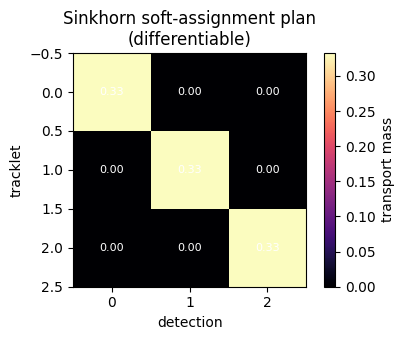

In [17]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(plan.detach().numpy(), cmap="magma", vmin=0)
ax.set_title("Sinkhorn soft-assignment plan\n(differentiable)")
ax.set_xlabel("detection"); ax.set_ylabel("tracklet")
for i in range(plan.shape[0]):
    for j in range(plan.shape[1]):
        ax.text(j, i, f"{plan[i, j]:.2f}", ha="center", va="center",
                color="white", fontsize=8)
plt.colorbar(im, ax=ax, label="transport mass")
plt.tight_layout(); plt.show()


The plan is sharp on the diagonal and the gradient is non-zero, so
the embeddings receive a learning signal *through the matcher*. To
get the same behavior inside a full tracker, build it with a single
flag — `ut.Tracker(..., differentiable=True)` — and unitrack swaps
every hard node (`Associate`, `Replace`, `StandardLifecycle`, …) for
its soft companion automatically. Combined with `ClipTracker`, that
is enough to train end-to-end across a clip.

## Where to go next

- **[Migration guide](../../docs/migration.md)** — the full
  1.x → 2.0 symbol map and a line-by-line port of this tracker.
- **Notebooks 1–6** — the library from the ground up: data model,
  cost & gate zoos, the pipeline tree, states & lifecycle.
- **`unitrack.tracker.BatchTracker`** — vmap-batched multi-stream
  inference. **`ClipTracker`** — clip-based methods (MinVIS,
  DVIS++).
- **Recipes** (`docs/recipes/`) — SORT and the overlap-IoU tracker
  as compact, self-contained builders.
